# **Experiment 10: Fine-Tuning a Small LLM and Downstream Evaluation**

**Aim**

To fine-tune a small pre-trained language model and evaluate its performance on unseen downstream data.

**Brief Theory**

Fine-tuning updates the parameters of a pre-trained model using task-specific examples. Validation loss helps monitor model performance during training, while an unseen test set provides an unbiased evaluation of the trained model. For text-generation tasks, Perplexity is an appropriate evaluation metric.

In [1]:
!pip install transformers datasets accelerate sentencepiece -q

import os
import json
import math
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)

print("Student Name: Abu Sayem")
print("Student ID: 25/SET/MTCE/014")
print("Libraries loaded successfully!")

Student Name: Abu Sayem
Student ID: 25/SET/MTCE/014
Libraries loaded successfully!


In [3]:
# Create/Load Custom Dataset from Experiment 9

data = [
    {
        "instruction": "What is Artificial Intelligence?",
        "response": "Artificial Intelligence is the field of creating machines that can perform tasks requiring human-like intelligence."
    },
    {
        "instruction": "What is Machine Learning?",
        "response": "Machine Learning is a branch of AI that allows computers to learn patterns from data."
    },
    {
        "instruction": "What is Deep Learning?",
        "response": "Deep Learning is a type of machine learning that uses neural networks with multiple layers."
    },
    {
        "instruction": "What is Computer Vision?",
        "response": "Computer Vision enables computers to understand and analyze images and videos."
    },
    {
        "instruction": "What is Natural Language Processing?",
        "response": "Natural Language Processing enables computers to process and understand human language."
    },
    {
        "instruction": "What is Generative AI?",
        "response": "Generative AI refers to AI systems that can generate new text, images, audio or other content."
    },
    {
        "instruction": "What is a Neural Network?",
        "response": "A Neural Network is a computational model inspired by the structure of the human brain."
    },
    {
        "instruction": "What is Data Science?",
        "response": "Data Science uses statistics, programming and machine learning to extract useful information from data."
    },
    {
        "instruction": "What is a Large Language Model?",
        "response": "A Large Language Model is an AI model trained on large amounts of text to understand and generate language."
    },
    {
        "instruction": "What is Fine-Tuning?",
        "response": "Fine-Tuning adapts a pre-trained model to perform better on a specific task or dataset."
    }
]

print("Dataset loaded successfully!")
print("Total records:", len(data))

Dataset loaded successfully!
Total records: 10


In [4]:
import random

random.seed(42)
random.shuffle(data)

train_data = data[:7]
validation_data = data[7:9]
test_data = data[9:10]

print("========== Dataset Split ==========")
print("Training samples:", len(train_data))
print("Validation samples:", len(validation_data))
print("Test samples:", len(test_data))

========== Dataset Split ==========
Training samples: 7
Validation samples: 2
Test samples: 1


In [5]:
# Load Base DistilGPT-2 Model
model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(model_name)

print("Base model loaded successfully!")
print("Model:", model_name)
print("Vocabulary Size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Base model loaded successfully!
Model: distilgpt2
Vocabulary Size: 50257


In [6]:
# Prepare Hugging Face Datasets
train_dataset = Dataset.from_list(train_data)
validation_dataset = Dataset.from_list(validation_data)
test_dataset = Dataset.from_list(test_data)

print("Datasets prepared successfully!")
print("Train:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Test:", len(test_dataset))

Datasets prepared successfully!
Train: 7
Validation: 2
Test: 1


In [7]:
# Tokenize Dataset
def tokenize_function(examples):

    texts = [
        "Instruction: " + instruction +
        "\nResponse: " + response
        for instruction, response
        in zip(examples["instruction"], examples["response"])
    ]

    return tokenizer(
        texts,
        truncation=True,
        max_length=128,
        padding="max_length"
    )


tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=train_dataset.column_names
)

tokenized_validation = validation_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=validation_dataset.column_names
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=test_dataset.column_names
)

print("Tokenization completed successfully!")

Map:   0%|          | 0/7 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Tokenization completed successfully!


In [8]:
# Record Initial Base Model Information
print("========== Initial Model Information ==========")
print("Model:", model_name)
print("Model Type: Causal Language Model")
print("Sequence Length: 128")
print("Initial Model: Pre-trained DistilGPT-2")
print("Fine-Tuning Status: Not yet trained")

========== Initial Model Information ==========
Model: distilgpt2
Model Type: Causal Language Model
Sequence Length: 128
Initial Model: Pre-trained DistilGPT-2
Fine-Tuning Status: Not yet trained


In [9]:
# Base Model on Unseen Test Data
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

base_args = TrainingArguments(
    output_dir="./base_evaluation",
    per_device_eval_batch_size=1,
    report_to="none"
)

base_trainer = Trainer(
    model=base_model,
    args=base_args,
    eval_dataset=tokenized_test,
    data_collator=data_collator
)

base_eval = base_trainer.evaluate()

base_loss = base_eval["eval_loss"]
base_perplexity = math.exp(base_loss)

print("========== Base Model Evaluation ==========")
print("Test Loss:", round(base_loss, 4))
print("Test Perplexity:", round(base_perplexity, 4))

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Training Loss,Validation Loss,Step
No log,3.279351,0


========== Base Model Evaluation ==========
Test Loss: 3.2794
Test Perplexity: 26.5585


In [10]:
# Create Fine-Tuning Configuration
training_args = TrainingArguments(
    output_dir="./fine_tuned_distilgpt2",
    num_train_epochs=1,
    max_steps=5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    learning_rate=5e-5,
    eval_strategy="steps",
    eval_steps=1,
    logging_steps=1,
    save_strategy="steps",
    save_steps=5,
    save_total_limit=1,
    report_to="none"
)

print("========== Fine-Tuning Configuration ==========")
print("Epochs:", 1)
print("Maximum Steps:", 5)
print("Batch Size:", 2)
print("Learning Rate:", 5e-5)
print("Sequence Length:", 128)
print("Evaluation Strategy: Every step")

========== Fine-Tuning Configuration ==========
Epochs: 1
Maximum Steps: 5
Batch Size: 2
Learning Rate: 5e-05
Sequence Length: 128
Evaluation Strategy: Every step


In [11]:
# Load a Fresh Model for Fine-Tuning
fine_tuned_model = AutoModelForCausalLM.from_pretrained(model_name)

fine_tuned_model.config.pad_token_id = tokenizer.pad_token_id

print("Fresh model loaded for fine-tuning!")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Fresh model loaded for fine-tuning!


In [12]:
# Create Data Collator
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

print("Causal Language Modeling data collator ready!")

Causal Language Modeling data collator ready!


In [13]:
# Configure Trainer
trainer = Trainer(
    model=fine_tuned_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    data_collator=data_collator
)

print("Trainer configured successfully!")

Trainer configured successfully!


In [14]:
# Fine-Tune the Model
print("Starting fine-tuning...")

start_time = time.time()

train_result = trainer.train()

training_time = time.time() - start_time

print("\n========== Training Completed ==========")
print("Training Steps:", train_result.global_step)
print("Training Time:", round(training_time, 2), "seconds")

Starting fine-tuning...


Step,Training Loss,Validation Loss
1,4.015126,3.159291
2,3.535202,2.960728
3,3.395087,2.834279
4,2.924029,2.762465
5,2.947810,2.726437


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


========== Training Completed ==========
Training Steps: 5
Training Time: 59.9 seconds


In [15]:
# Save Fine-Tuned Checkpoint
checkpoint_path = "./fine_tuned_distilgpt2"

trainer.save_model(checkpoint_path)
tokenizer.save_pretrained(checkpoint_path)

print("Fine-tuned model saved successfully!")
print("Checkpoint:", checkpoint_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model saved successfully!
Checkpoint: ./fine_tuned_distilgpt2


In [16]:
# Validation Evaluation
validation_result = trainer.evaluate()

validation_loss = validation_result["eval_loss"]
validation_perplexity = math.exp(validation_loss)

print("========== Validation Evaluation ==========")
print("Validation Loss:", round(validation_loss, 4))
print("Validation Perplexity:", round(validation_perplexity, 4))

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step
2.947810,2.726437,5


========== Validation Evaluation ==========
Validation Loss: 2.7264
Validation Perplexity: 15.2784


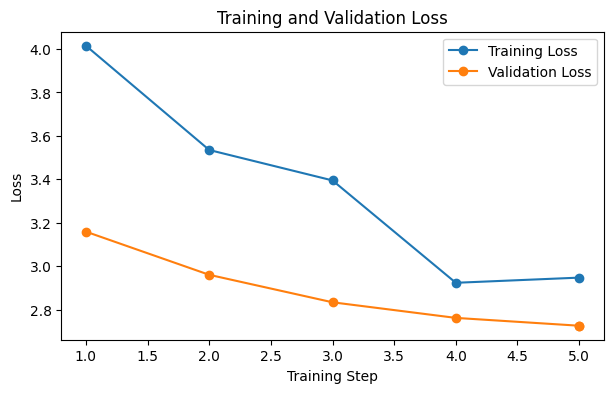

In [17]:
# Plot Training and Validation Loss
logs = trainer.state.log_history

train_steps = []
train_losses = []

eval_steps = []
eval_losses = []

for log in logs:

    if "loss" in log and "eval_loss" not in log:
        if "step" in log:
            train_steps.append(log["step"])
            train_losses.append(log["loss"])

    if "eval_loss" in log:
        if "step" in log:
            eval_steps.append(log["step"])
            eval_losses.append(log["eval_loss"])


plt.figure(figsize=(7, 4))

if train_steps:
    plt.plot(train_steps, train_losses, marker="o", label="Training Loss")

if eval_steps:
    plt.plot(eval_steps, eval_losses, marker="o", label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [18]:
# Evaluate Fine-Tuned Model on Unseen Test Data
fine_test_result = trainer.evaluate(
    eval_dataset=tokenized_test
)

fine_test_loss = fine_test_result["eval_loss"]
fine_test_perplexity = math.exp(fine_test_loss)

print("========== Fine-Tuned Model Test ==========")
print("Test Loss:", round(fine_test_loss, 4))
print("Test Perplexity:", round(fine_test_perplexity, 4))

Training Loss,Validation Loss,Step
2.947810,2.697101,5


========== Fine-Tuned Model Test ==========
Test Loss: 2.6971
Test Perplexity: 14.8367


In [19]:
# Base vs Fine-Tuned Comparison
comparison = pd.DataFrame({
    "Model": [
        "Base DistilGPT-2",
        "Fine-Tuned DistilGPT-2"
    ],
    "Test Loss": [
        round(base_loss, 4),
        round(fine_test_loss, 4)
    ],
    "Test Perplexity": [
        round(base_perplexity, 4),
        round(fine_test_perplexity, 4)
    ]
})

print("========== Base vs Fine-Tuned ==========")
print(comparison.to_string(index=False))

========== Base vs Fine-Tuned ==========
                 Model  Test Loss  Test Perplexity
      Base DistilGPT-2     3.2794          26.5585
Fine-Tuned DistilGPT-2     2.6971          14.8367


Interpretation

Lower perplexity generally indicates that the model assigns higher probability to the test text and is therefore modeling that text better.

In [20]:
# Test Example Generation
test_instruction = test_data[0]["instruction"]

prompt = "Instruction: " + test_instruction + "\nResponse:"

inputs = tokenizer(
    prompt,
    return_tensors="pt"
)

# Base model
base_model.eval()

with torch.no_grad():
    base_output = base_model.generate(
        **inputs,
        max_new_tokens=40,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

base_text = tokenizer.decode(
    base_output[0],
    skip_special_tokens=True
)

# Fine-tuned model
fine_tuned_model.eval()

with torch.no_grad():
    fine_output = fine_tuned_model.generate(
        **inputs,
        max_new_tokens=40,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

fine_text = tokenizer.decode(
    fine_output[0],
    skip_special_tokens=True
)

print("========== Downstream Test ==========")
print("Input:", test_instruction)

print("\nBase Model Output:")
print(base_text)

print("\nFine-Tuned Model Output:")
print(fine_text)

========== Downstream Test ==========
Input: What is Machine Learning?

Base Model Output:
Instruction: What is Machine Learning?
Response: Machine Learning is a new way to learn and learn. Machine learning is a new way to learn and learn. Machine learning is a new way to learn and learn. Machine learning is a new way to

Fine-Tuned Model Output:
Instruction: What is Machine Learning?
Response: Machine Learning is a new field of research that has been growing in recent years. Machine learning is a new field of research that has been growing in recent years. Machine learning is a new field of research


In [21]:
print("\n========== EXPERIMENT 10 SUMMARY ==========")

print("Student Name: Abu Sayem")
print("Student ID: 25/SET/MTCE/014")

print("\nModel:")
print("Base Model: DistilGPT-2")
print("Fine-Tuned Model: DistilGPT-2")

print("\nDataset:")
print("Total:", len(data))
print("Train:", len(train_data))
print("Validation:", len(validation_data))
print("Test:", len(test_data))

print("\nTraining Configuration:")
print("Learning Rate: 5e-5")
print("Batch Size: 2")
print("Epochs: 1")
print("Maximum Steps: 5")
print("Sequence Length: 128")

print("\nEvaluation:")
print("Base Test Perplexity:", round(base_perplexity, 4))
print("Fine-Tuned Test Perplexity:", round(fine_test_perplexity, 4))

print("\nCheckpoint:")
print("./fine_tuned_distilgpt2")


========== EXPERIMENT 10 SUMMARY ==========
Student Name: Abu Sayem
Student ID: 25/SET/MTCE/014

Model:
Base Model: DistilGPT-2
Fine-Tuned Model: DistilGPT-2

Dataset:
Total: 10
Train: 7
Validation: 2
Test: 1

Training Configuration:
Learning Rate: 5e-5
Batch Size: 2
Epochs: 1
Maximum Steps: 5
Sequence Length: 128

Evaluation:
Base Test Perplexity: 26.5585
Fine-Tuned Test Perplexity: 14.8367

Checkpoint:
./fine_tuned_distilgpt2


**Observation / Result**

**Observation**

The pre-trained DistilGPT-2 model was fine-tuned using the custom instruction-response dataset prepared in Experiment 9. Training and validation losses were recorded during fine-tuning. The fine-tuned model was saved as a checkpoint and evaluated on an unseen test example.

The original base model was also evaluated on the same unseen test data.

**Result**

The Base DistilGPT-2 and Fine-Tuned DistilGPT-2 models were compared using test loss and perplexity. The generated outputs were also inspected qualitatively.

The fine-tuning result should be interpreted carefully because the custom dataset is very small.